In [1]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print("Path to dataset files:", path)

100%|██████████| 163M/163M [00:01<00:00, 106MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt



from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
os.listdir(os.path.join(path, "data"))

['with_mask', 'without_mask']

In [4]:
# ================================
# CELL 5 — DEFINE DATASET PATH
# ================================

dataset_path = os.path.join(path, "data")

print(dataset_path)

/root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1/data


In [5]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10

In [6]:
# ================================
# CELL 7 — DATA AUGMENTATION
# ================================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    validation_split=0.3
)

In [7]:
# ================================
# CELL 8 — TRAIN GENERATOR
# ================================

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

Found 5288 images belonging to 2 classes.


In [8]:
# ================================
# CELL 9 — VALIDATION GENERATOR
# ================================

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 2265 images belonging to 2 classes.


In [9]:
print(train_generator.class_indices)

{'with_mask': 0, 'without_mask': 1}


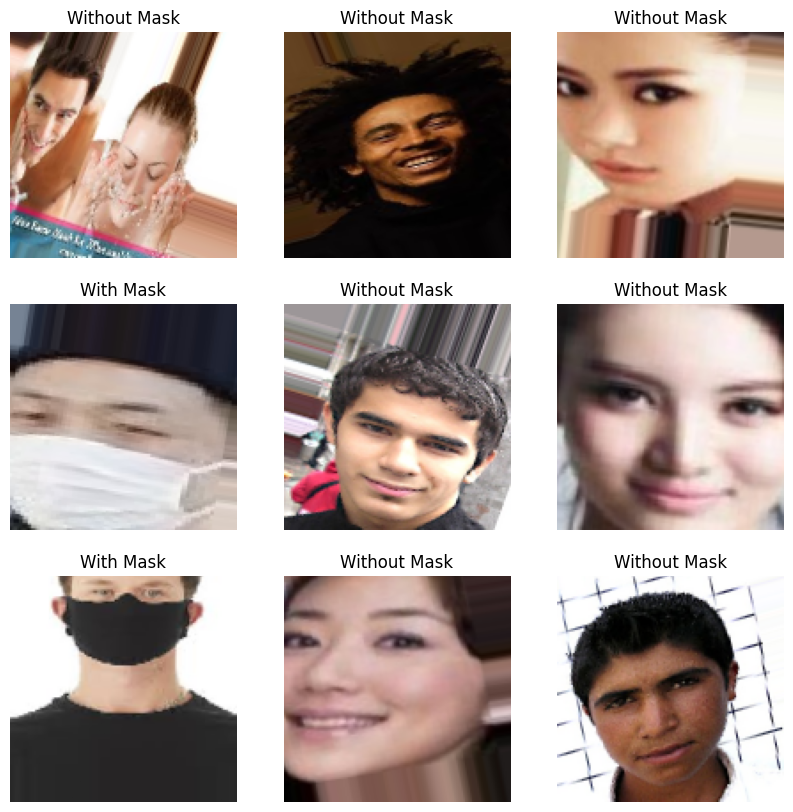

In [10]:
# ================================
# CELL 11 — DISPLAY SAMPLE IMAGES
# ================================

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    if labels[i] == 0:
        plt.title("With Mask")
    else:
        plt.title("Without Mask")

    plt.axis("off")

plt.show()

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.optimizers import Adam # Import Adam optimizer here

model = Sequential([

    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Smarter replacement for Flatten
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.4),

    Dense(1, activation='sigmoid') # Correct output layer for binary classification
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,619 (1.62 MB)

 Trainable params: 422,659 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
# This cell is no longer needed as model compilation is moved to cell 1zRo2kjMo0ku
# ================================
# CELL 14 — COMPILE MODEL
# ================================

# model.compile(
#     optimizer=Adam(learning_rate=0.001),
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [19]:
# ================================
# CELL 16 — TRAIN MODEL
# ================================

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/10
 85/166 ━━━━━━━━━━━━━━━━━━━━ 19s 243ms/step - accuracy: 0.7090 - loss: 0.6102

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


166/166 ━━━━━━━━━━━━━━━━━━━━ 66s 336ms/step - accuracy: 0.7683 - loss: 0.4892 - val_accuracy: 0.5068 - val_loss: 2.9059
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 44s 264ms/step - accuracy: 0.8882 - loss: 0.2733 - val_accuracy: 0.5461 - val_loss: 1.1673
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 54s 323ms/step - accuracy: 0.9249 - loss: 0.1950 - val_accuracy: 0.6755 - val_loss: 1.0026
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 44s 267ms/step - accuracy: 0.9476 - loss: 0.1461 - val_accuracy: 0.8971 - val_loss: 0.2445
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 44s 263ms/step - accuracy: 0.9554 - loss: 0.1280 - val_accuracy: 0.9289 - val_loss: 0.1789
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 44s 266ms/step - accuracy: 0.9627 - loss: 0.1075 - val_accuracy: 0.9276 - val_loss: 0.1687
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 43s 262ms/step - accuracy: 0.9575 - loss: 0.1135 - val_accuracy: 0.7214 - val_loss: 1.1845
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 45s 268ms/step - accuracy: 0.9703 - loss: 0.0856 - val

In [20]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - accuracy: 0.9329 - loss: 0.1690
Validation Loss: 0.16898997128009796
Validation Accuracy: 0.932891845703125


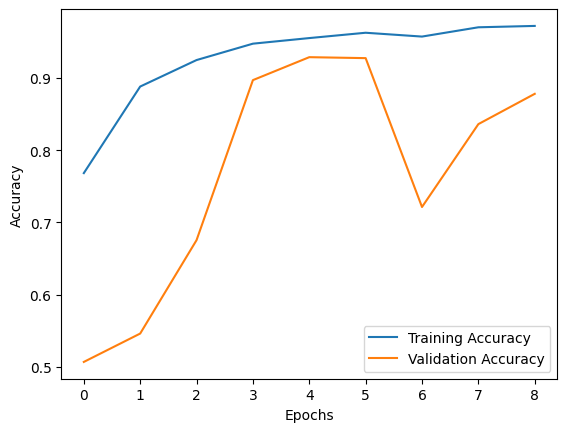

In [21]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

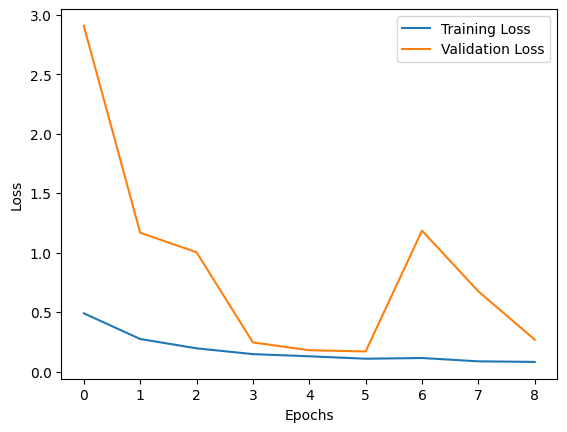

In [22]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 171ms/step


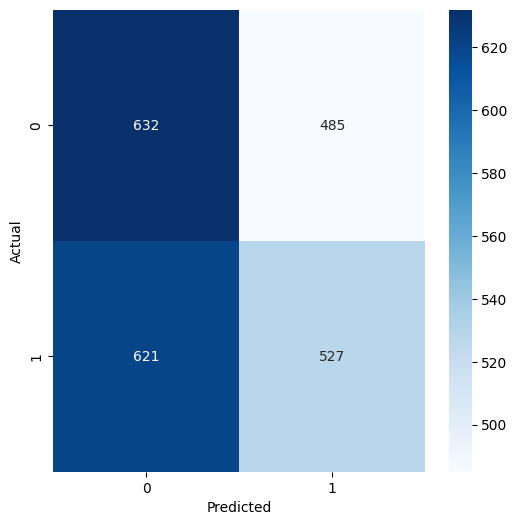

In [23]:
# ================================
# CELL 23 — CONFUSION MATRIX
# ================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(validation_generator)

predicted_labels = (predictions > 0.5).astype(int)

true_labels = validation_generator.classes

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
# ================================
# CELL 24 — CLASSIFICATION REPORT
# ================================

from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predicted_labels
))

              precision    recall  f1-score   support

           0       0.50      0.57      0.53      1117
           1       0.52      0.46      0.49      1148

    accuracy                           0.51      2265
   macro avg       0.51      0.51      0.51      2265
weighted avg       0.51      0.51      0.51      2265



In [25]:
model.save("face_mask_detector.keras")
